# Plot from dicts

## Bring ***dat_col*** from df_77_97_mrn and multiple ***XLroot_tbls*** for ***plotting and processing***

### ***imports*** 

In [1]:
# Imports required for Loading, sorting .csv files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
#import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
import ipywidgets as widgets 
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
#from sys_funcs import 

### ***dat_col name glossary ***

### ***det functions***

#### ***read & write from Local Storage***

In [76]:
# def read_from_pkl(name):   # name is a string: read_from_pkl("ib_dct")import pickle
def read_from_pkl(name):
    filename = f"{name}.pkl"
    # print(filename)
    with open(filename, "rb") as f:
        loaded_obj = pickle.load(f)
    globals()[name] = loaded_obj
    print(f"{name} updated from {filename}")


In [77]:
read_from_pkl("df_77_97_mrn")

df_77_97_mrn updated from df_77_97_mrn.pkl


In [7]:
#  def write_to_pkl(name):   # name is a string: write_to_pkl("ib_dct")
import pickle
import inspect

def write_to_pkl(name):   # name is a string: write_to_pkl("ib_dct")
    # Access caller frame
    frame = inspect.currentframe().f_back

    # Pull the object from caller's local variables
    if name not in frame.f_locals:
        raise NameError(f"Variable '{name}' does not exist in caller scope")

    obj = frame.f_locals[name]

    # Write to pickle
    filename = f"{name}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(obj, f)

    print(f"{name} written to {filename}")
    return None


#### read and clean ***dat_vol*** from ***XLroot tables***

In [8]:
def clean_colname(name):                                 # RETURNS THE CLEANED UP NAME 
    """
    Strip hidden, zero-width, and non-printing characters.
    Normalize Unicode. Remove control chars.
    """
    if not isinstance(name, str):
        name = str(name)

    # Normalize Unicode
    name = unicodedata.normalize("NFKC", name)

    # Remove zero-width characters
    name = re.sub(r"[\u200B-\u200D\uFEFF]", "", name)

    # Remove control characters
    name = re.sub(r"[\x00-\x1F\x7F]", "", name)

    # Strip whitespace (including non-breaking)
    name = name.replace("\xa0", " ").strip()

    return name


In [9]:
# def read froms XL table to Jupyter dict
import pandas as pd
from pathlib import Path
from openpyxl import load_workbook

XL_PATH = "/home/ratlabs/JL_2/data/dat_mnl/dat_mnl.xlsm"

def import_xl_table(table_nm):
    """
    Import an Excel table by name from XL_PATH and return a dict of Series.
    """

    xl_path = Path(XL_PATH)

    wb = load_workbook(xl_path, data_only=True)

    # Find sheet containing the table
    sheet_with_table = None
    for ws in wb.worksheets:
        if table_nm in ws.tables:
            sheet_with_table = ws
            break

    if sheet_with_table is None:
        raise ValueError(f"Table '{table_nm}' not found in workbook.")

    tbl = sheet_with_table.tables[table_nm]
    ref = tbl.ref  # e.g. "A1:F200"

    # --- REQUIRED FIX: convert "A1:F200" → "A:F" ---
    start_cell, end_cell = ref.split(":")
    start_col = ''.join(filter(str.isalpha, start_cell))
    end_col   = ''.join(filter(str.isalpha, end_cell))
    col_range = f"{start_col}:{end_col}"

    # Now pandas can read it
    df = pd.read_excel(
        xl_path,
        sheet_name=sheet_with_table.title,
        usecols=col_range,
        engine="openpyxl"
    )

    return {col: df[col] for col in df.columns}


In [7]:
#TTD def write to XL

#### ***Slct_frm_or_add_to root_dat_dct***

In [4]:
def find_rows_by_name(plt_lst_dct, plt_lst_nm):                             
    """
    Returns a dict of all rows where row_dict[0] == plt_lst_nm.
    Example: plt_lst_nm = 'smm_vfa'
    """
    matches = {
        row_id: row_dict
        for row_id, row_dict in plt_lst_dct.items()
        if row_dict.get(0) == plt_lst_nm
    }
    return matches


In [60]:
def add_plt_list_safe(plt_lst_dct, plt_lst_nm, plt_lst):  # 🧠 Step 2 — Main add function with decision logic
    """
    Safe add: enforces unique list names.
    Returns:
        - row_id if added
        - return with a note " already added into "plt_lst_dct == ***delete duplicate*** before running to replace "  plt_lst_nm"  
    """

    existing = check_existing_list_name(plt_lst_dct, plt_lst_nm)

    if existing is not None:
        return {
            "status": "exists",
            "row_id": existing,
            "message": f"List name '{plt_lst_nm}' already exists in row {existing}",
            "options": [
                "[**delete duplicate*** before running to replace "
            ]
        }

    # Normal add
    next_idx = len(plt_lst_dct) + 1
    row_key = f"row_{next_idx:03d}"

    row = {0: plt_lst_nm}
    for i, item in enumerate(plt_lst, start=1):
        row[i] = item

    plt_lst_dct[row_key] = row
    return {"status": "added", "row_id": row_key}


##### ***select, add, edit, or delete***

In [5]:
def dispatch_plt_list(plt_lst_dct, plt_lst_nm):              # :create a list of favorite dat_col Note
    """
    Dispatcher: retrieves the list stored under a given list name (plt_lst_nm)
    inside plt_lst_dct.

    Structure expected:
        row[k][0] = list name
        row[k][1..N] = list elements
    """

    # 1. Find the row where key 0 matches the list name
    for row_id, row in plt_lst_dct.items():
        if row.get(0) == plt_lst_nm:
            # 2. Extract values 1..N in order
            max_key = max(row.keys())
            extracted = [row[i] for i in range(1, max_key + 1)]
            return extracted

    # 3. If not found → deterministic failure
    raise KeyError(f"List name '{plt_lst_nm}' not found in plt_lst_dct")


In [67]:
def delete_row(plt_lst_dct, row_id):
    """
    Deletes a row (e.g., 'row_001') from plt_lst_dct safely.
    Returns True if deleted, False if the row did not exist.
    """
    if row_id in plt_lst_dct:
        plt_lst_dct.pop(row_id)
        return True
    return False


In [70]:
def delete_row_by_name(plt_lst_dct, plt_lst_nm):
    """
    Deletes the row whose key 0 matches plt_lst_nm.
    Example: key 0 == 'smm_vfa'
    Raises KeyError if no matching row is found.
    """
    # Find the row_id whose entry has key 0 equal to plt_lst_nm
    for row_id, row_dict in plt_lst_dct.items():
        if row_dict.get(0) == plt_lst_nm:
            plt_lst_dct.pop(row_id)
            return row_id  # return which row was deleted

    raise KeyError(f"No row found with plt_lst_nm='{plt_lst_nm}'")


In [11]:
def get_ctrl_row(unq_row_nm, ctrl_dct):                # FINDS THE ROW THAT MATCH PLT_LST_NM AND RETURN THAT ROW OF KEY VALUES
    target = clean_colname(unq_row_nm)                # Makes sure target is clean so it will match one of the cleaned keys

    for row_key, row in ctrl_dct.items():             # cleans all of key0  until it finds a clean one.
        stored = clean_colname(row.get(0))

        if stored == target:
            return [row[k] for k in sorted(row.keys()) if k != 0]

    raise KeyError(f"Control '{unq_row_nm}' not found after cleaning.")


##### calc  ***dtv_range***  :  strt:***dtv_strt_val*** stp:***dtv_stp_val*** 

In [228]:
def get_dtv_range(dct, row_nm):
    """
    Given dtv_rng_dct and a row name, return (dtv_strt, dtv_stp)
    for the matching row.
    """

    rows = dct['rows_nm']

    # Normalize rows_nm into a pandas Index
    if hasattr(rows, "index") and not isinstance(rows, list):
        # rows is a Series → use its values
        if hasattr(rows, "values"):
            rows_index = pd.Index(rows.values)
        else:
            rows_index = pd.Index(rows)
    else:
        # rows is a list
        rows_index = pd.Index(rows)

    # Lookup
    try:
        idx = rows_index.get_loc(row_nm)
    except KeyError:
        raise ValueError(f"Row name '{row_nm}' not found in rows_nm")

    # Extract aligned values
    dtv_strt_val = dct['dtv_strt'][idx]
    dtv_stp_val  = dct['dtv_stp'][idx]

    return dtv_strt_val, dtv_stp_val


##### **multiplots** from ***dtcl_prs_dct(*dtco_prs_nm*), strt_dtv=None, stp_dtv=None, save_pdf=True***

In [180]:
def plot_multi_dual(df, *cols, strt_dtv=None, stp_dtv=None, save_pdf=True):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import os, re

    # --- SAFE COPY ---
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # --- APPLY dtv FILTER IF PROVIDED ---
    if strt_dtv is not None:
        df = df[df["dtv"] >= strt_dtv]

    if stp_dtv is not None:
        df = df[df["dtv"] <= stp_dtv]

    # If filtering removed everything, fail loudly and deterministically
    if df.empty:
        raise ValueError(f"No rows remain after dtv filtering: {strt_dtv=} {stp_dtv=}")

    # --- COLOR CYCLE ---
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # --- LEFT AXIS ---
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # --- RIGHT AXES STACK ---
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # --- X‑AXIS CONTROL ---
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()

    # --- SAVE BLOCK ---
    if save_pdf:
        save_dir = "/mnt/c/Users/bhuns/OneDrive/___ib_plots"
        os.makedirs(save_dir, exist_ok=True)

        chart_title = " vs ".join(cols)
        chart_title = chart_title.replace("/", "_")
        chart_title = re.sub(r'[^A-Za-z0-9_-]+', '_', chart_title)

        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        chart_title = f"{timestamp}_{chart_title}"

        pdf_path = f"{save_dir}/{chart_title}.pdf"
        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    plt.show()


#### ***Call_functions***

##### Import ***Dictionaries***

In [13]:
read_from_pkl("df_77_97_mrn")

df_77_97_mrn.pkl
df_77_97_mrn updated from df_77_97_mrn.pkl


In [84]:
# verify     df_77_97_mrn   # OK

##### ***plt_lst_dct***

In [170]:
read_from_pkl("plt_lst_dct")

plt_lst_dct updated from plt_lst_dct.pkl


plt_lst_dct

In [43]:
# Reset  plt_lst_dct = {}

In [54]:
# verify Reset   plt_lst_dct

In [52]:
# Define a new list to add to plt_lst_dct
plt_lst = ["smm_(skeletal_muscle_mass)","vfa_(visceral_fat_area)"]
plt_lst_nm = "smm_vfa"

In [162]:
plt_lst

['smm_(skeletal_muscle_mass)', 'vfa_(visceral_fat_area)']

In [57]:
plt_lst_nm          # 1st 3 letters of each of the 2 "dat_col_nm"s

'smm_vfa'

# ***dtcl_prs_dct***

#### BE SURE TO COPY ***"dat_mnl.xlsm"*** from OneDrive to WSL

1. from onedrive where edits are made.
2. TO WSL where Jupyter gets the data
3. Using desktop macro before importing

### Load Plotting or Processing ***dat_col*** into a ***dtcl_prs*** frm ***XLtbls***

In [221]:
# BE SURE TO COPY "DAT_MNL"[CONTAINS ALL DAT TABLES] TO WSL BECAUSE jUPYTER ONLY READS FOR WSL DIRECTORIES
# COPY USE MACRO FROM DESKTOP ****************[copy_dat_mnl]************************
dtcl_prs_dct = import_xl_table("dtcl_prs")       #This reads "dtcl_prs" table in XL to "dtcl_prs_dct" in Jupyter 

/home/ratlabs/JL_2/.venv/lib/python3.8/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [194]:
# verity the list of dct keys dtcl_prs_dct.keys()


dict_keys(['RowID', 'dtcl_pr_nm', 'dct_i', 'key_i', 'dct_j ', 'key_j', 'Comments'])

In [1]:
# verity dtcl_prs_dct   
dtcl_prs_dct

NameError: name 'dtcl_prs_dct' is not defined

### Load Plotting or Processing ***dtv_rng*** into ***dtv_strt*** & ***dtv_stp***  frm ***XLtbls***

In [215]:
# BE SURE TO COPY "DAT_MNL"[CONTAINS ALL DAT TABLES] TO WSL BECAUSE jUPYTER ONLY READS FOR WSL DIRECTORIES
# COPY USE MACRO FROM DESKTOP ****************[copy_dat_mnl]************************
dtv_rng_dct = import_xl_table("dtv_rng")       #This reads "dtcl_prs" table in XL to "dtcl_prs_dct" in Jupyter 

/home/ratlabs/JL_2/.venv/lib/python3.8/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [219]:
# verity the list of dct keys  ....   dtv_rng_dct.keys()

In [223]:
# verity dtcl_prs_dct   
dtv_rng_dct

{'rows_nm': 0    last200
 Name: rows_nm, dtype: object,
 'dtv_strt': 0    46000
 Name: dtv_strt, dtype: int64,
 'dtv_stp': 0    46200
 Name: dtv_stp, dtype: int64}

In [229]:
dtv_strt, dtv_stp = get_dtv_range(dtv_rng_dct, "last200")


In [230]:
dtv_strt, dtv_stp

(46000, 46200)

In [176]:
rows = find_rows_by_name(dtcl_prs_dct, "smm_vfa")
print(rows)

{}


In [177]:
rows = find_rows_by_name(plt_lst_dct, "smm_vfa")
print(rows)


{'row_001': {0: 'smm_vfa', 1: 'smm_(skeletal_muscle_mass)', 2: 'vfa_(visceral_fat_area)'}, 'row_002': {0: 'smm_vfa', 1: 'smm_(skeletal_muscle_mass)', 2: 'vfa_(visceral_fat_area)'}, 'row_003': {0: 'smm_vfa', 1: 'smm_(skeletal_muscle_mass)', 2: 'vfa_(visceral_fat_area)'}}


# print (dtcl_prs_dct["smm_vfa"])


##### ADD a single "dat_col" to existing "plt_list": A ***plt_lst*** with a ***plt_lst_nm*** is added to a ***plt_lst_dct***

In [182]:
result = add_plt_list_safe(plt_lst_dct, "smm_vfa", "plt_lst")           # ✅ Step 1 — Attempt to add
result


{'status': 'exists',
 'row_id': 'row_001',
 'message': "List name 'smm_vfa' already exists in row row_001",
 'options': ['[**delete duplicate*** before running to replace ']}

In [167]:
deleted = delete_row(plt_lst_dct, "row_002")
print("Deleted:", deleted)


Deleted: True


In [61]:
# RESET    plt_lst_dct = {} # use only when creating a new plt_lst_dct 

In [184]:
write_to_pkl("plt_lst_dct")


plt_lst_dct written to plt_lst_dct.pkl


#### DISPATCH the ***plt_lst***  with  ***plt_lst_nm*** from ***plt_lst_dct***

In [55]:
plt_lst = dispatch_plt_list(plt_lst_dct, "smm_vfa")

In [56]:
# verify plt_lst  # ok:

#### Select ***plt_lst***   from ***plt_lst_dct*** key 0:plt_lst_nm

In [57]:
plt_lst = get_ctrl_row("smm_vfa", plt_lst_dct)

In [58]:
# verify plt_lst      #OK

#### Create ***plt_lst_dct***            key 0:plt_lst_nm

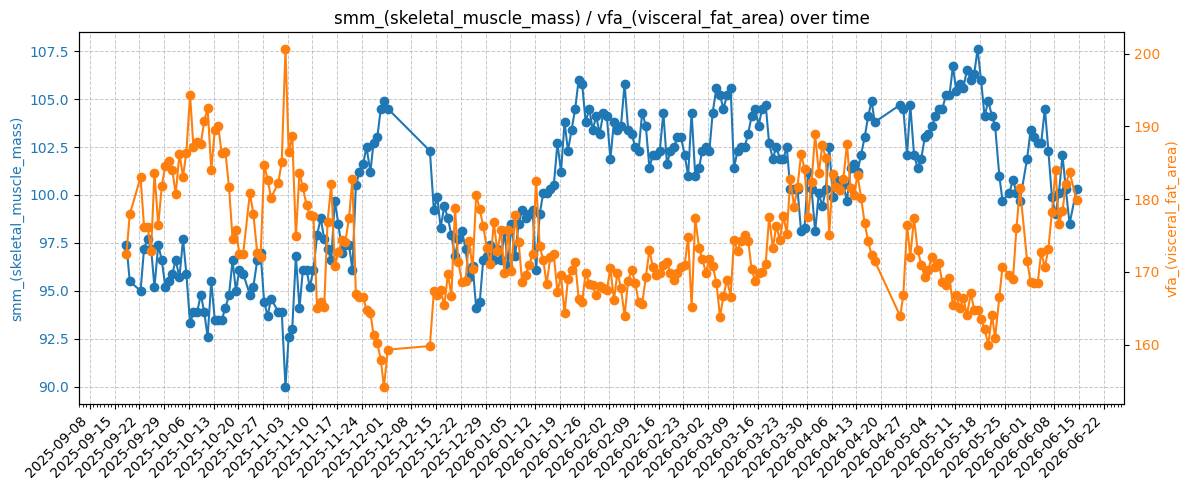

In [59]:
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
# plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

## Plot from Dcts

In [5]:
read_from_pkl("df_77_97_mrn")


df_77_97_mrn.pkl
df_77_97_mrn updated from df_77_97_mrn.pkl


In [75]:
# verify df_77_97_mrn

In [74]:
# verify plt_lst_dct